# Notebook 2: Variational Quantum Algorithms — VQE & QAOA

This notebook demonstrates two core variational algorithms:

1. **VQE** (Variational Quantum Eigensolver) — find the ground state energy of a Hamiltonian
2. **QAOA** (Quantum Approximate Optimization Algorithm) — solve combinatorial optimization problems

In [3]:
!pip install matplotlib

zsh:1: /Users/vinhpx/Workspaces/Learning/qforge/.venv/bin/pip: bad interpreter: /Users/vinhpx/Workspaces/Learning/Quantum_Virtual_Machine/.venv/bin/python3.14: no such file or directory


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qforge.circuit import Qubit
from qforge.gates import H, CNOT, RY, RZ
from qforge.measurement import pauli_expectation
from qforge.algo.hamiltonian import Hamiltonian
from qforge.algo.gradient import parameter_shift
from qforge.algo.optimizers import Adam, GradientDescent
from qforge.algo.ansatz import hardware_efficient_ansatz
from qforge.algo.vqe import VQE
from qforge.algo.qaoa import QAOA

---
## Part 1: VQE — Ground State of H₂

We approximate the H₂ molecular Hamiltonian as a 2-qubit Pauli sum:

$$H = c_0 I + c_1 Z_0 + c_2 Z_1 + c_3 Z_0 Z_1 + c_4 X_0 X_1$$

The exact ground state energy is approximately **-1.137 Ha**.

In [2]:
# H2 Hamiltonian at equilibrium bond length (simplified)
h2_hamiltonian = Hamiltonian(
    coeffs=[-0.4804, 0.3435, -0.4347, 0.5716, 0.0910],
    terms=[
        [],              # Identity
        [('Z', 0)],      # Z0
        [('Z', 1)],      # Z1
        [('Z', 0), ('Z', 1)],  # Z0 Z1
        [('X', 0), ('X', 1)],  # X0 X1
    ]
)
print("H2 Hamiltonian constructed with 5 Pauli terms")

H2 Hamiltonian constructed with 5 Pauli terms


### 1a. Manual VQE loop

To understand what VQE does under the hood, let's build it step by step.

In [3]:
n_qubits = 2
n_layers = 2
n_params = VQE.n_params_hardware_efficient(n_qubits, n_layers)
print(f"Parameters: {n_params} (n_qubits={n_qubits}, n_layers={n_layers})")

# Cost function: prepare state with ansatz, measure energy
def cost_fn(params):
    wf = Qubit(n_qubits)
    hardware_efficient_ansatz(wf, params, n_layers=n_layers)
    return h2_hamiltonian.expectation(wf)

# Initialize random parameters
np.random.seed(42)
params = np.random.uniform(-np.pi, np.pi, n_params)
print(f"Initial energy: {cost_fn(params):.6f} Ha")

Parameters: 6 (n_qubits=2, n_layers=2)
Initial energy: -0.891057 Ha


In [4]:
# Manual optimization loop with parameter-shift gradients
optimizer = Adam(lr=0.05)
history = []

for step in range(80):
    energy = cost_fn(params)
    history.append(energy)
    grad = parameter_shift(cost_fn, params)
    params = optimizer.step(params, grad)
    if step % 20 == 0:
        print(f"Step {step:3d}: E = {energy:.6f} Ha, |grad| = {np.linalg.norm(grad):.4f}")

print(f"\nFinal energy:  {history[-1]:.6f} Ha")
print(f"Exact ground:  -1.1370 Ha")
print(f"Error:         {abs(history[-1] - (-1.137)):.4f} Ha")

Step   0: E = -0.891057 Ha, |grad| = 1.2655
Step  20: E = -1.778621 Ha, |grad| = 0.4209
Step  40: E = -1.826119 Ha, |grad| = 0.1567
Step  60: E = -1.834251 Ha, |grad| = 0.0605

Final energy:  -1.835383 Ha
Exact ground:  -1.1370 Ha
Error:         0.6984 Ha


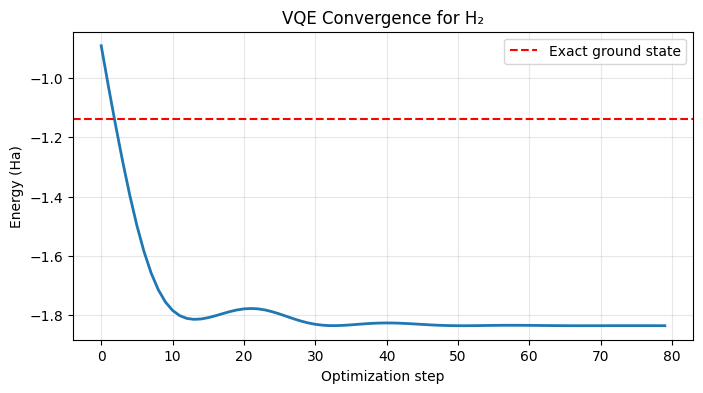

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(history, linewidth=2)
plt.axhline(y=-1.137, color='r', linestyle='--', label='Exact ground state')
plt.xlabel('Optimization step')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence for H₂')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1b. Using the VQE class

The `VQE` class wraps the full loop.

VQE result: E = -1.835387 Ha


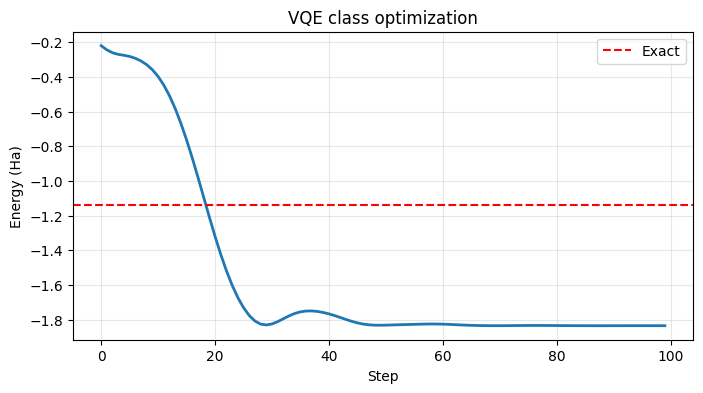

In [6]:
vqe = VQE(n_qubits=2, hamiltonian=h2_hamiltonian, n_layers=2)

np.random.seed(0)
init_params = np.random.uniform(-np.pi, np.pi, vqe.n_params_hardware_efficient(2, 2))

opt_params, vqe_history = vqe.optimize(
    params=init_params,
    optimizer=Adam(lr=0.05),
    steps=100
)

print(f"VQE result: E = {vqe_history[-1]:.6f} Ha")

plt.figure(figsize=(8, 4))
plt.plot(vqe_history, linewidth=2)
plt.axhline(y=-1.137, color='r', linestyle='--', label='Exact')
plt.xlabel('Step')
plt.ylabel('Energy (Ha)')
plt.title('VQE class optimization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Part 2: QAOA — Max-Cut Problem

Given a graph, find the partition of vertices that maximizes the number of edges between the two groups.

We solve Max-Cut on a small graph:

```
0 --- 1
|     |
3 --- 2
```

In [7]:
# Define the graph as edges
edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
n_qubits = 4

qaoa = QAOA(n_qubits=n_qubits, edges=edges, p_layers=2)
print(f"QAOA parameters: {qaoa.n_params} (2 * p_layers)")

QAOA parameters: 4 (2 * p_layers)


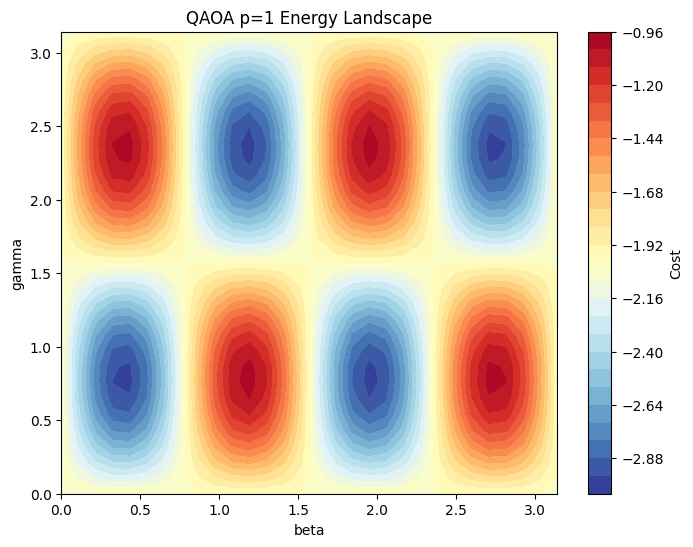

In [8]:
qaoa_p1 = QAOA(n_qubits=n_qubits, edges=edges, p_layers=1)

gammas = np.linspace(0, np.pi, 30)
betas = np.linspace(0, np.pi, 30)
landscape = np.zeros((len(gammas), len(betas)))

for i, g in enumerate(gammas):
    for j, b in enumerate(betas):
        wf = Qubit(n_qubits)
        qaoa_p1.circuit_fn(wf, np.array([g, b]))
        landscape[i, j] = qaoa_p1.cost_fn(wf)

plt.figure(figsize=(8, 6))
plt.contourf(betas, gammas, landscape, levels=30, cmap='RdYlBu_r')
plt.colorbar(label='Cost')
plt.xlabel('beta')
plt.ylabel('gamma')
plt.title('QAOA p=1 Energy Landscape')
plt.show()

In [9]:
# Extract the solution
solution = qaoa.get_solution(opt_params, n_samples=1000)
print(f"Best bitstring: |{solution['bitstring']}>")
print(f"Cut value: {solution['cut_value']}")
print(f"Max possible cut: 4 (for a square graph)")

# Show top measurement outcomes
print("\nTop measurement outcomes:")
sorted_idx = np.argsort(-solution['counts'])
for idx in sorted_idx[:5]:
    bs = solution['samples'][idx]
    c = solution['counts'][idx]
    print(f"  |{bs}> : {c} times")

Best bitstring: |0101>
Cut value: 4
Max possible cut: 4 (for a square graph)

Top measurement outcomes:
  |0101> : 125 times
  |1010> : 111 times
  |0110> : 77 times
  |1001> : 70 times
  |0011> : 65 times


### QAOA landscape

For `p=1`, we can visualize the energy landscape over the two parameters (gamma, beta).

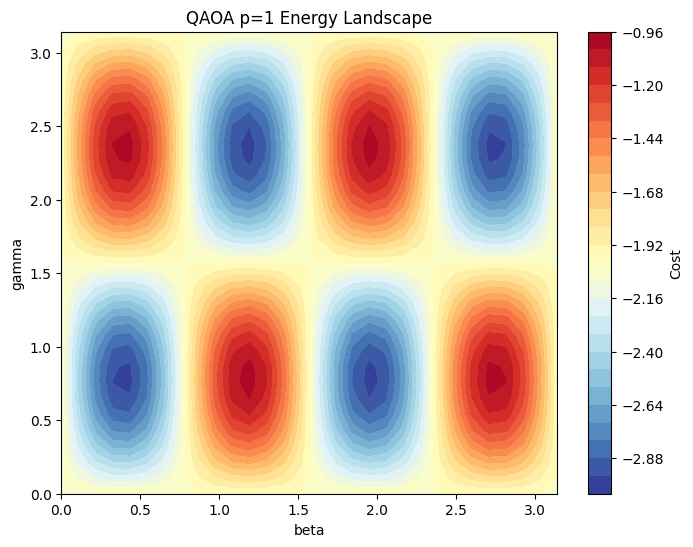

In [12]:
qaoa_p1 = QAOA(n_qubits=n_qubits, edges=edges, p_layers=1)

gammas = np.linspace(0, np.pi, 30)
betas = np.linspace(0, np.pi, 30)
landscape = np.zeros((len(gammas), len(betas)))

for i, g in enumerate(gammas):
    for j, b in enumerate(betas):
        wf = Qubit(n_qubits)
        qaoa_p1.circuit_fn(wf, np.array([g, b]))
        landscape[i, j] = qaoa_p1.cost_fn(wf)


plt.figure(figsize=(8, 6))
plt.contourf(betas, gammas, landscape, levels=30, cmap='RdYlBu_r')
plt.colorbar(label='Cost')
plt.xlabel('beta')
plt.ylabel('gamma')
plt.title('QAOA p=1 Energy Landscape')
plt.show()